In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# Tashkent city housing_data
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.sample(5)

,location,district,rooms,size,level,max_levels,price
5568,"город Ташкент, Чиланзарский район, Чиланзар 5-...",Чиланзарский,3,78,1,5,68000
6541,"город Ташкент, Яккасарайский район, 7-й проезд...",Яккасарайский,3,105,5,9,135000
1503,"город Ташкент, Мирзо-Улугбекский район, Буюк И...",Мирзо-Улугбекский,1,25,3,4,21500
369,"город Ташкент, Чиланзарский район, Алгоритм",Чиланзарский,2,44,4,4,29500
6282,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,55,4,4,43000


In [ ]:
df.columns

Index(['location', 'district', 'rooms', 'size', 'level', 'max_levels',
       'price'],
      dtype='object')

In [ ]:
df.shape

(7565, 7)

In [ ]:
df.describe()

,rooms,level,max_levels
count,7565.000000,7565.000000,7565.000000
mean,2.625644,3.699273,6.038202
std,1.085201,2.237275,2.613271
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,5.000000
75%,3.000000,5.000000,9.000000
max,10.000000,19.000000,25.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


In [ ]:
# duplications
df.duplicated().sum()

np.int64(700)

In [ ]:
df = df.drop_duplicates()

***district is enough and we need it,that's why location is deleted***




In [ ]:
df = df.drop('location',axis=1)

**the price and size columns are  object ,so i change them to float**


In [ ]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['size'] = pd.to_numeric(df['size'], errors='coerce')

In [ ]:
# find out NaN values
df.isnull().sum()

,0
district,0
rooms,0
size,1
level,0
max_levels,0
price,96


***missing values are deleted***


In [ ]:
df = df.dropna(subset=['price'])
df = df.dropna(subset=['size'])

In [ ]:
df.shape

(6768, 6)

In [ ]:
df.isnull().sum()

,0
district,0
rooms,0
size,0
level,0
max_levels,0
price,0


In [ ]:
df.columns

Index(['district', 'rooms', 'size', 'level', 'max_levels', 'price'], dtype='object')

In [ ]:
df['max_levels'].unique()

array([ 4,  5,  9, 12,  3, 11,  7, 19,  2,  8, 16,  6, 10,  1, 23, 25, 13,
       18, 17, 22, 14, 20])

In [ ]:
df['level'].unique()

array([ 4,  1,  3,  2,  5,  6,  7,  9, 11, 18,  8, 10, 16, 12, 13, 14, 15,
       19])

In [ ]:
df['rooms'].unique()

array([ 3,  2,  1,  4,  5,  8,  6,  7, 10])

***Feature Engineering***

In [ ]:
#calculate the price per square meter
df['price_per_m2'] = df['price'] / df['size']

In [ ]:
#avg_room_size
df['avg_room_size'] = df['size'] / df['rooms']

In [ ]:
df['is_top_floor'] = (df['level'] == df['max_levels']).astype(int)

In [ ]:
df['size_category'] = pd.cut(
    df['size'],
    bins=[0, 40, 80, 120, 200, 500],
    labels=['small', 'medium', 'large', 'very_large', 'luxury']
)

In [ ]:
df.sample(5)

,district,rooms,size,level,max_levels,price,price_per_m2,avg_room_size,is_top_floor,size_category
6562,Чиланзарский,3,78.0,9,9,53500.0,685.897436,26.0,1,medium
1466,Чиланзарский,2,58.0,7,9,42000.0,724.137931,29.0,0,medium
5527,Яккасарайский,2,118.0,7,8,90000.0,762.711864,59.0,0,large
4360,Шайхантахурский,2,68.0,4,4,70000.0,1029.411765,34.0,1,medium
3344,Учтепинский,2,46.0,4,4,32500.0,706.521739,23.0,1,medium


**EDA**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

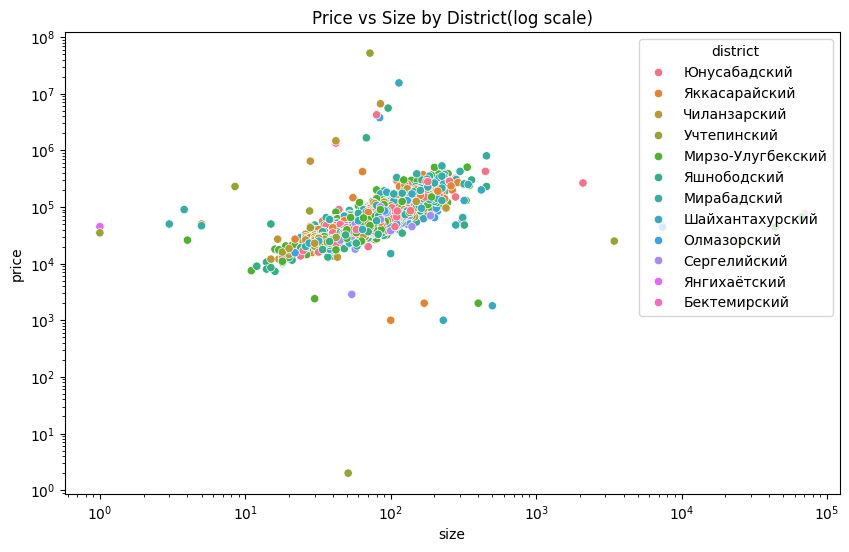

In [ ]:
# we can see outliers values
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='size', y='price', hue='district')
plt.title('Price vs Size by District(log scale)')
plt.xscale('log')
plt.yscale('log')
plt.show()

*REMOVE OUTLIERS*

In [ ]:
# Cleaning outliers
print(df['size'].sort_values(ascending=False).head(15))
df = df[df['size'] < 501]
df = df[df['size']>17]
df = df[df['price']<=530000.0]
df = df[df['price']>=10000.0]
df = df[df['level'] <= df['max_levels']]

2547    70000.0
4615    69000.0
5456    67000.0
3089    44000.0
2268    24500.0
7043     7407.0
4784     7359.0
981      7359.0
2662     3448.0
7421     2100.0
4089      500.0
1695      456.0
1693      456.0
1557      448.0
5197      420.0
Name: size, dtype: float64


In [ ]:
print(df['size'].sort_values(ascending=True).head(30))

7563    18.0
7505    18.0
7474    18.0
975     18.0
7031    18.0
1041    18.0
3635    18.0
4356    18.0
6055    18.0
4365    18.0
2659    18.0
2650    18.0
2658    18.0
5176    18.0
2166    18.0
3087    18.0
5158    18.0
2349    19.0
6873    20.0
4578    20.0
473     20.0
2652    20.0
4989    20.0
4984    20.0
1234    20.0
3865    20.0
81      20.0
1434    20.0
6338    20.0
110     20.0
Name: size, dtype: float64


In [ ]:
df.shape

(6717, 10)

In [ ]:
def remove_sqm_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('district'):
        m = np.mean(subdf.price_per_m2)
        st = np.std(subdf.price_per_m2)
        reduced_df = subdf[(subdf.price_per_m2 > (m - st)) & (subdf.price_per_m2 <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df = remove_sqm_outliers(df)

In [ ]:
# find out houses whose price is less than 65,000, but whose size is more than 200 ,these are error values
filtered_houses = df[(df['price'] <= 65000) & (df['size'] > 200)]
print(filtered_houses)

# drop filtered_houses
df = df.drop(filtered_houses.index)

Empty DataFrame
Columns: [district, rooms, size, level, max_levels, price, price_per_m2, avg_room_size, is_top_floor, size_category]
Index: []


In [ ]:
# drop outliers in a logical way
outliers = df[(df['price'] >= 150000) & (df['size'] < 100)]

df = df.drop(outliers.index)

In [ ]:
outliers2 = df[(df['price'] >= 400000) & (df['size'] < 250)]
print(outliers2)
df = df.drop(outliers2.index)

Empty DataFrame
Columns: [district, rooms, size, level, max_levels, price, price_per_m2, avg_room_size, is_top_floor, size_category]
Index: []


In [ ]:
outliers3 = df[(df['price'] <= 150000) & (df['size'] > 300)]
print(outliers3)
df = df.drop(outliers3.index)

Empty DataFrame
Columns: [district, rooms, size, level, max_levels, price, price_per_m2, avg_room_size, is_top_floor, size_category]
Index: []


***EDA***

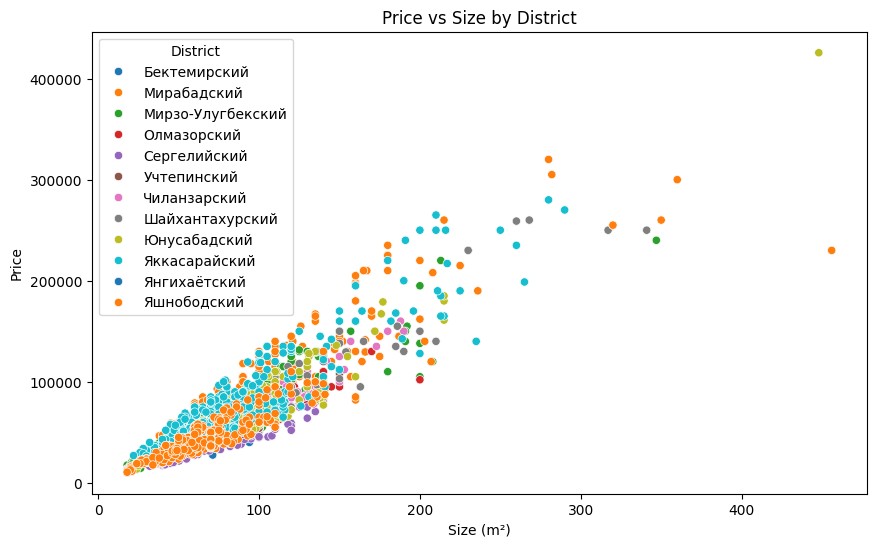

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='size', y='price', hue='district', palette='tab10')
plt.title('Price vs Size by District')
plt.xlabel('Size (m²)')
plt.ylabel('Price')
plt.legend(title='District')
plt.show()

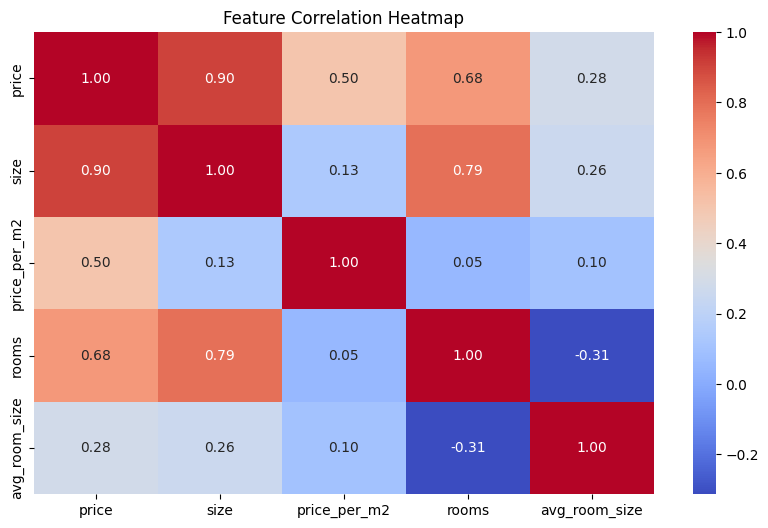

In [ ]:
plt.figure(figsize=(10, 6))
corr = df[['price','size','price_per_m2','rooms','avg_room_size']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
df.select_dtypes(include=np.number).corrwith(df['price']).sort_values(ascending=False)

,0
price,1.000000
size,0.903611
rooms,0.675641
price_per_m2,0.504210
avg_room_size,0.284037
max_levels,0.261166
level,0.114199
is_top_floor,-0.121599


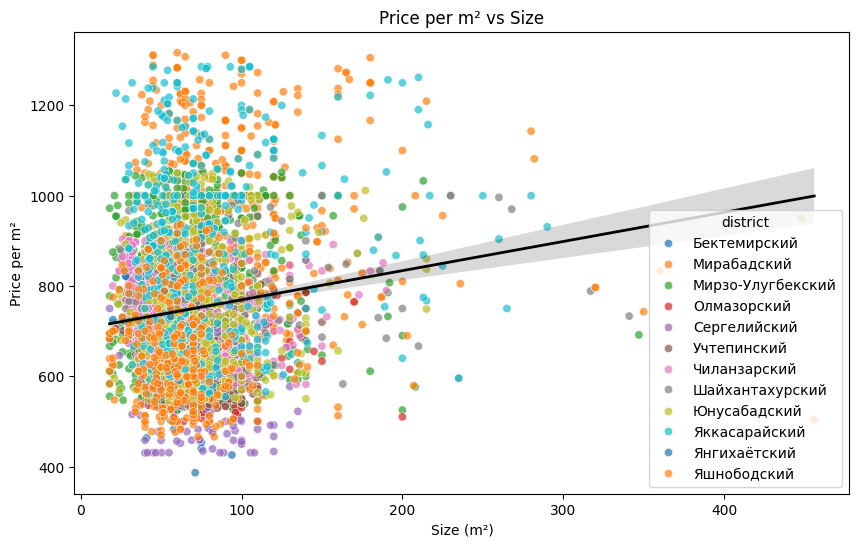

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='size', y='price_per_m2', hue='district', palette='tab10', alpha=0.7)
sns.regplot(data=df, x='size', y='price_per_m2', scatter=False, color='black', line_kws={'lw':2})
plt.title('Price per m² vs Size')
plt.xlabel('Size (m²)')
plt.ylabel('Price per m²')
plt.show()

In [ ]:
outliers4 = df[(df['price_per_m2'] >= 2500) & (df['size'] < 100)]
outliers4.head(10)
df = df.drop(outliers4.index)

As a result of the analysis, I found out that houses on the  4 floors were sold a lot, followed by 2, 3, 1 floors , these houses are in 4, 5, 9-story buildings, most of them are on the 4th floor. 2-room and 3-room houses are sold a lot in between




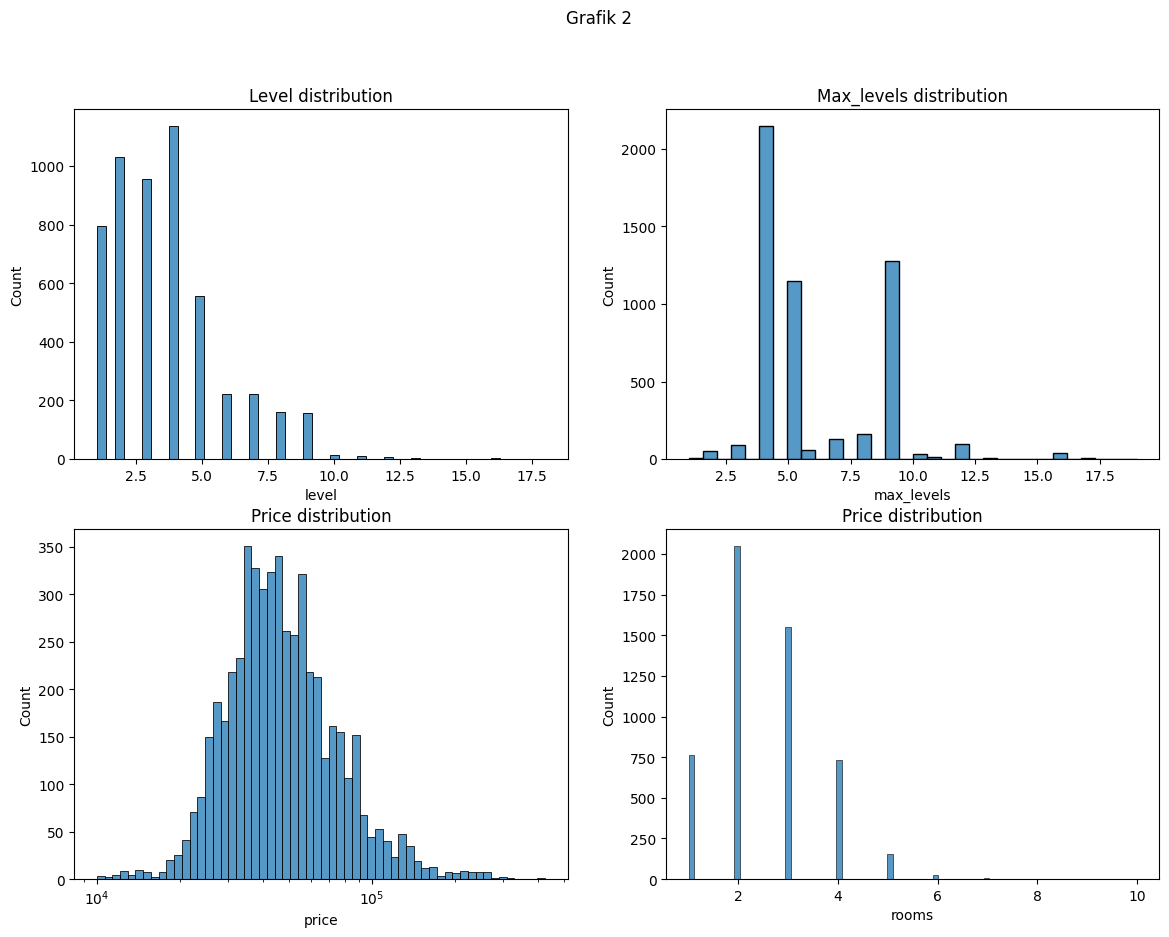

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Grafik 2")
sns.histplot(ax=ax[0, 0], data=df, x='level')
sns.histplot(ax=ax[0, 1], data=df, x='max_levels')
sns.histplot(ax=ax[1, 0], data=df, x='price',log_scale=True)
sns.histplot(ax=ax[1, 1], data=df, x='rooms')

ax[0,0].set_title("Level distribution")
ax[0,1].set_title("Max_levels distribution")
ax[1,0].set_title("Price distribution")
ax[1,1].set_title("Price distribution")
plt.show()

Many houses were sold in Chilonzor and Mirza Ulugbek districts,followed by Yunusabad and Uchtepa.

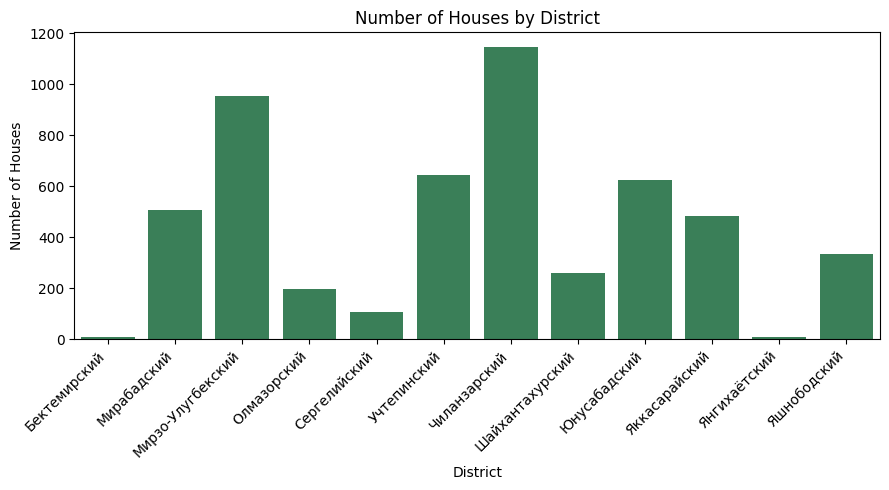

In [ ]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='district',color='seagreen')

plt.title('Number of Houses by District')
plt.xlabel('District')
plt.ylabel('Number of Houses')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
district_avg = df.groupby('district')['price_per_m2'].mean()

 In Mirabad and Yakkasaroy district ,price of houses are higher than other

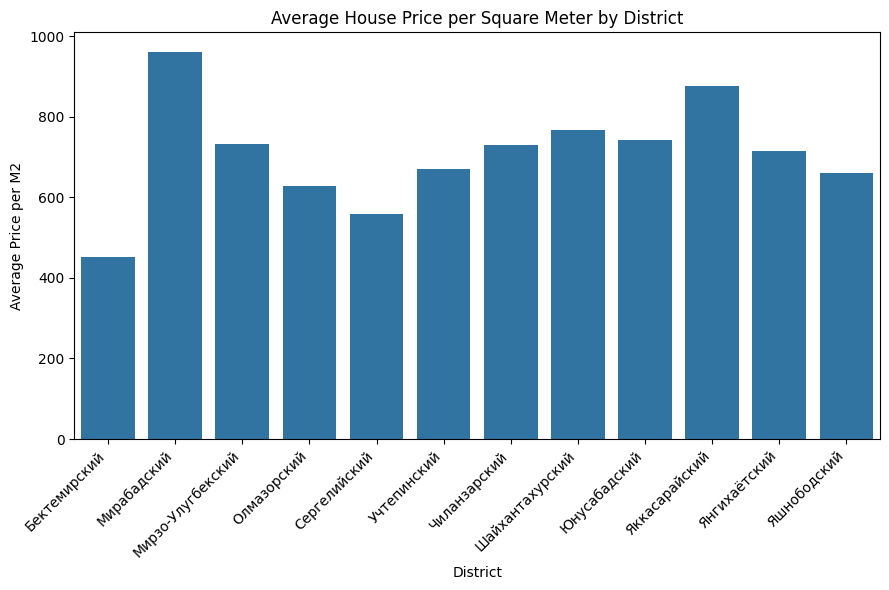

In [ ]:
plt.figure(figsize=(9, 6))

plot_df = district_avg.reset_index()
plot_df.columns = ['district', 'avg_price_per_m2']

sns.barplot(data=plot_df, x='district', y='avg_price_per_m2')

plt.title('Average House Price per Square Meter by District')
plt.xlabel('District')
plt.ylabel('Average Price per M2')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# the five most expensive houses
df.sort_values(by='price',ascending=False).head(5)

,district,rooms,size,level,max_levels,price,price_per_m2,avg_room_size,is_top_floor,size_category
3941,Юнусабадский,10,448.0,7,7,425600.0,950.000000,44.800000,1,luxury
68,Мирабадский,4,280.0,4,8,320000.0,1142.857143,70.000000,0,luxury
282,Мирабадский,4,282.0,7,8,305000.0,1081.560284,70.500000,0,luxury
5047,Яшнободский,7,360.0,5,6,300000.0,833.333333,51.428571,0,luxury
4652,Яккасарайский,5,280.0,1,8,280000.0,1000.000000,56.000000,0,luxury


In [ ]:
# the five cheapest houses
df.sort_values(by='price',ascending=True).head(5)

,district,rooms,size,level,max_levels,price,price_per_m2,avg_room_size,is_top_floor,size_category
1038,Мирзо-Улугбекский,1,18.0,4,4,10000.0,555.555556,18.0,1,small
5247,Яшнободский,1,18.0,1,4,10500.0,583.333333,18.0,0,small
1341,Мирзо-Улугбекский,1,18.0,6,9,10500.0,583.333333,18.0,0,small
1469,Мирзо-Улугбекский,1,18.0,1,4,11000.0,611.111111,18.0,0,small
5052,Яшнободский,1,18.0,2,4,11000.0,611.111111,18.0,0,small


In [ ]:
# find out houses's size than higher 200
df[df['size']>200].shape

(43, 10)

/tmp/ipython-input-474/1272733986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rooms', y='price', palette='Set2')


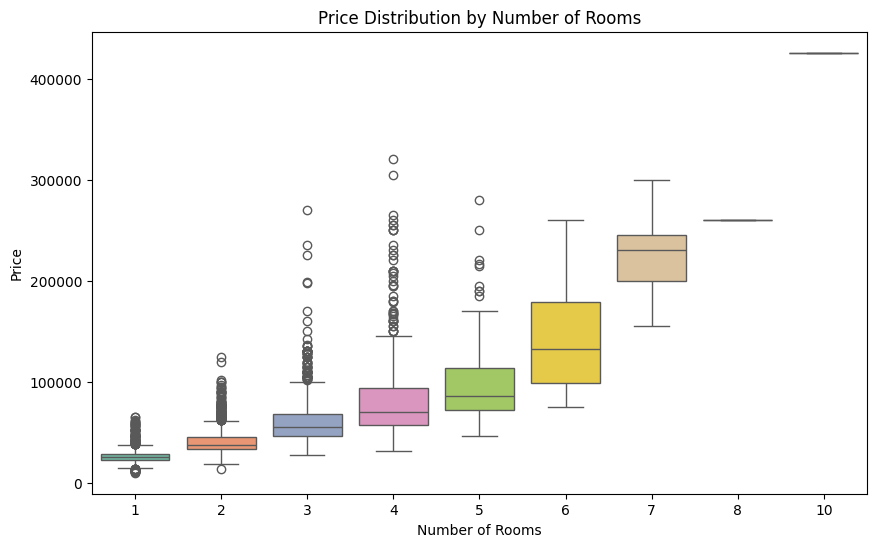

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='rooms', y='price', palette='Set2')
plt.title('Price Distribution by Number of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Price')
plt.show()

***Preprocessing***

In [ ]:
# we do not need 'price_per_m2' column ,we only pay attention 'price'
df = df.drop(columns=['price_per_m2'])

In [ ]:
# we change some columns to integer
df['rooms'] = df['rooms'].astype(int)
df['level'] = df['level'].astype(int)
df['max_levels'] = df['max_levels'].astype(int)

In [ ]:
df = df[df['level'] <= df['max_levels']]
df = df[df['level'] > 0]

In [ ]:
df = df[df['rooms'] > 0]

In [ ]:
# NaN values does not exist
df.isnull().sum()

,0
district,0
rooms,0
size,0
level,0
max_levels,0
price,0
avg_room_size,0
is_top_floor,0
size_category,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
X = df.drop(columns=['price'])
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
df.columns

Index(['district', 'rooms', 'size', 'level', 'max_levels', 'price',
       'avg_room_size', 'is_top_floor', 'size_category'],
      dtype='object')

***Pipeline***

In [ ]:
numeric_features = ['size', 'rooms', 'level', 'max_levels', 'avg_room_size']
categorical_features = ['district', 'size_category', 'is_top_floor']

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
y_train.shape, y_test.shape

((4220,), (1056,))

***Machine learning modeling***

***RandomForest***

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_processed, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test_processed)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 6790.603791809947
RMSE: 10555.403345225895
R2: 0.8805747431687113


In [ ]:
predicted_data = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_rf})
predicted_data

,Actual,Predicted
8,80000.0,73406.904762
655,44000.0,41114.530574
3103,42000.0,49973.629834
4576,95000.0,93190.530000
465,98000.0,89860.000000
...,...,...
274,110000.0,111791.172071
4550,135000.0,128062.770000
2378,63000.0,51150.750000
1181,30299.0,34553.229618


***Cross Validation(CV)***

In [ ]:
#xgboost
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_scores = cross_val_score(
    xgb_reg, X_train_processed, y_train,
    scoring="neg_mean_squared_error", cv=10
)
xgb_rmse_scores = np.sqrt(-xgb_scores)

print(f"XGBoost Mean RMSE: {xgb_rmse_scores.mean():.4f}")
print(f"XGBoost RMSE Stability: {xgb_rmse_scores.std():.4f}")


XGBoost Mean RMSE: 10348.1957
XGBoost RMSE Stability: 1362.8862


***RandomizedSearchCV***

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    RandomForestRegressor(),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    n_jobs=-1,
    scoring='r2'
)

search.fit(X_train_processed, y_train)


final_model = search.best_estimator_


accuracy = final_model.score(X_test_processed, y_test)
print(f"{accuracy:.2%}")

88.18%
